<a href="https://www.kaggle.com/code/sonawanelalitsunil/ipl-2025-highlights?scriptVersionId=230234801" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ipl-2025-records/matches.csv
/kaggle/input/ipl-2025-records/deliveries.csv


## Title: IPL 2025 Highlights

### Key records and top performances from the IPL 2025 season.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv('/kaggle/input/ipl-2025-records/matches.csv')

In [4]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 22,2025","Eden Gardens, Kolkata",KKR,RCB,League,RCB,Bowl,174,8,177,3,RCB,7 wickets,22,Krunal Pandya,Virat Kohli,59,Krunal Pandya,3--29
1,2,"March 23,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,RR,League,RR,Bowl,286,6,242,6,SRH,44 runs,0,Ishan Kishan,Ishan Kishan,106,Tushar Deshpande,3--44
2,3,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Bowl,155,9,158,6,CSK,4 wickets,5,Noor Ahmad,Rachin Ravindra,65,Noor Ahmad,4--18
3,4,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Bowl,209,8,211,9,DC,1 wickets,3,Ashutosh Sharma,Nicholas Pooran,75,Mitchell Starc,3--42
4,5,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,GT,Bowl,243,5,232,5,PBKS,11 runs,0,Shreyas Iyer,Shreyas Iyer,97,Sai Kishore,3--30


In [5]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
2,3,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Bowl,155,9,158,6,CSK,4 wickets,5,Noor Ahmad,Rachin Ravindra,65,Noor Ahmad,4--18
3,4,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Bowl,209,8,211,9,DC,1 wickets,3,Ashutosh Sharma,Nicholas Pooran,75,Mitchell Starc,3--42
4,5,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,GT,Bowl,243,5,232,5,PBKS,11 runs,0,Shreyas Iyer,Shreyas Iyer,97,Sai Kishore,3--30
5,6,"March 26,2025","Barsapara Stadium, Guwahati",RR,KKR,League,KKR,Bowl,151,9,153,2,KKR,8 wickets,15,Quinton de Kock,Quinton de Kock,97,Varun Chakravarthy,2--17
6,7,"March 27,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,LSG,League,LSG,Bowl,190,9,193,5,LSG,5 wickets,23,Shardul Thakur,Nicholas Pooran,70,Shardul Thakur,4--34


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             7 non-null      int64 
 1   date                 7 non-null      object
 2   venue                7 non-null      object
 3   team1                7 non-null      object
 4   team2                7 non-null      object
 5   stage                7 non-null      object
 6   toss_winner          7 non-null      object
 7   toss_decision        7 non-null      object
 8   first_ings_score     7 non-null      int64 
 9   first_ings_wkts      7 non-null      int64 
 10  second_ings_score    7 non-null      int64 
 11  second_ings_wkts     7 non-null      int64 
 12  match_winner         7 non-null      object
 13  won_by               7 non-null      object
 14  balls_left           7 non-null      int64 
 15  player_of_the_match  7 non-null      object
 16  top_scorer  

In [7]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,balls_left,highscore
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,4.000000,201.142857,7.714286,195.142857,5.142857,9.714286,81.285714
std,2.160247,49.191559,1.603567,34.868460,2.267787,10.094789,18.409366
min,1.000000,151.000000,5.000000,153.000000,2.000000,0.000000,59.000000
25%,2.500000,164.500000,7.000000,167.500000,4.000000,1.500000,67.500000
50%,4.000000,190.000000,8.000000,193.000000,5.000000,5.000000,75.000000
75%,5.500000,226.000000,9.000000,221.500000,6.000000,18.500000,97.000000
max,7.000000,286.000000,9.000000,242.000000,9.000000,23.000000,106.000000


In [8]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
balls_left             0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

match_id                int64
date                   object
venue                  object
team1                  object
team2                  object
stage                  object
toss_winner            object
toss_decision          object
first_ings_score        int64
first_ings_wkts         int64
second_ings_score       int64
second_ings_wkts        int64
match_winner           object
won_by                 object
balls_left              int64
player_of_the_match    object
top_scorer             object
highscore               int64
best_bowling           object
best_bowling_figure    object
dtype: object

In [11]:
df.shape

(7, 20)

In [12]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'balls_left', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

## Data visualizations

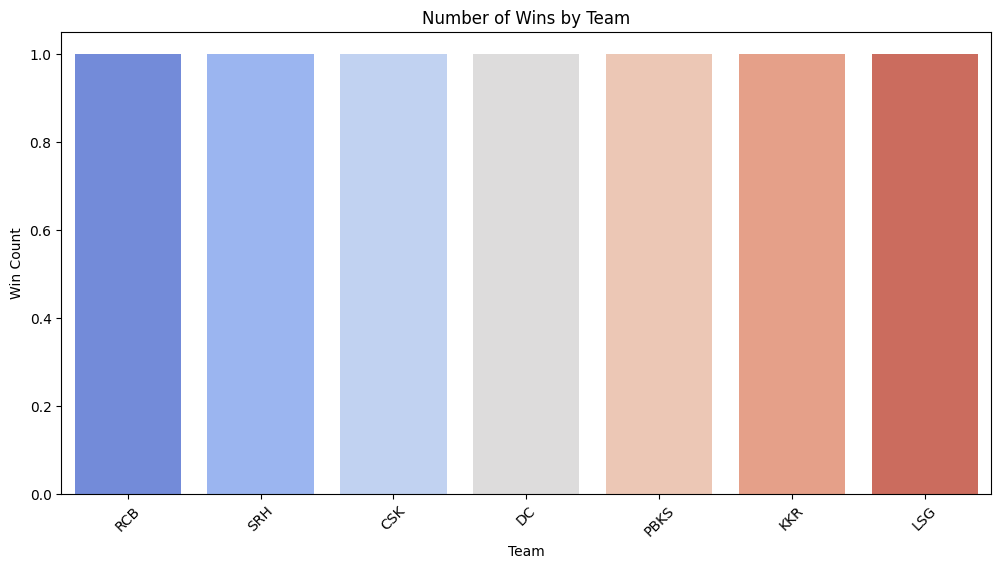

In [13]:
# 1. Bar Chart: Number of Wins by Team
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="match_winner", order=df["match_winner"].value_counts().index, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Number of Wins by Team")
plt.xlabel("Team")
plt.ylabel("Win Count")
plt.show()

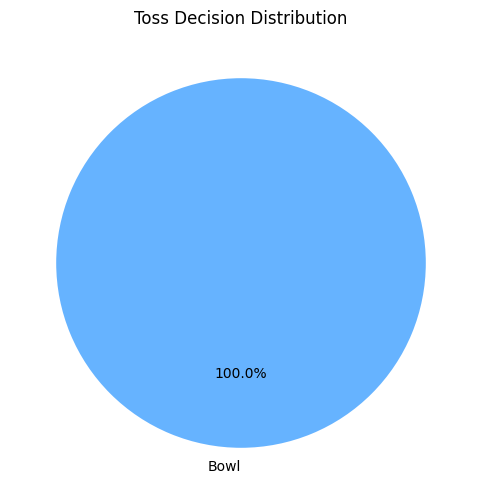

In [14]:
# 2. Pie Chart: Toss Decision Distribution
plt.figure(figsize=(6, 6))
df["toss_decision"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#66b3ff", "#99ff99"], startangle=90)
plt.title("Toss Decision Distribution")
plt.ylabel("")
plt.show()

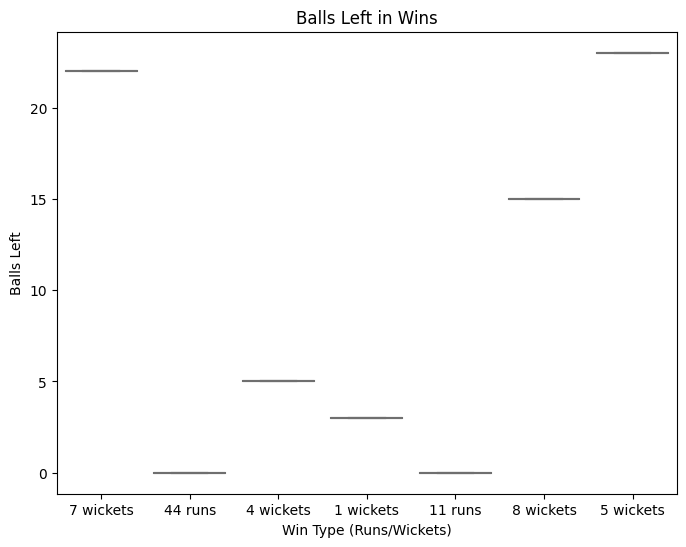

In [15]:
# 3. Box Plot: Balls Left in Wins
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="won_by", y="balls_left", palette="pastel")
plt.title("Balls Left in Wins")
plt.xlabel("Win Type (Runs/Wickets)")
plt.ylabel("Balls Left")
plt.show()

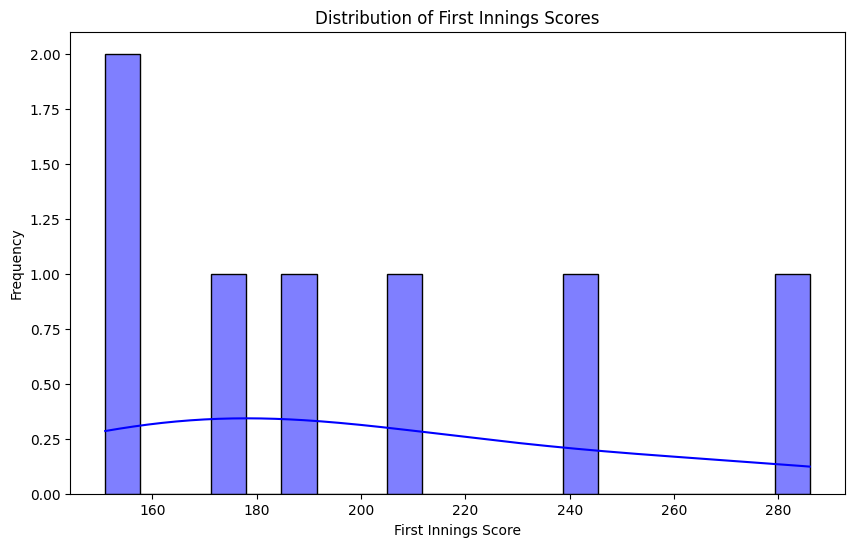

In [16]:
# 4. Histogram: First Innings Scores Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["first_ings_score"], bins=20, kde=True, color="blue")
plt.title("Distribution of First Innings Scores")
plt.xlabel("First Innings Score")
plt.ylabel("Frequency")
plt.show()

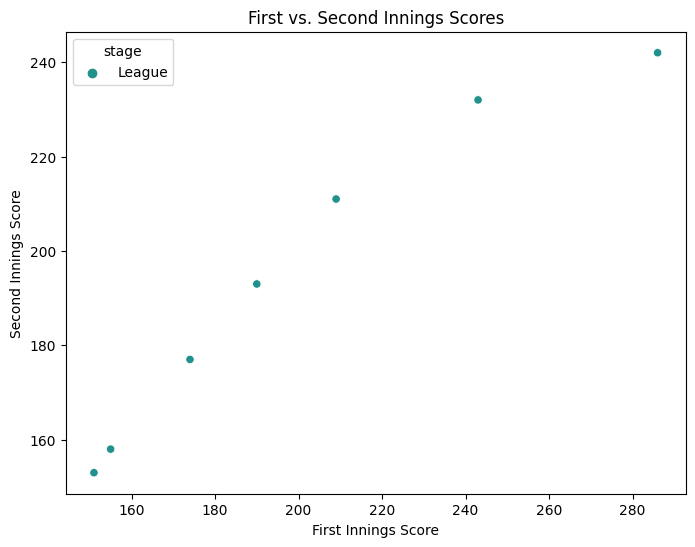

In [17]:
# 5. Scatter Plot: First vs. Second Innings Scores
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="first_ings_score", y="second_ings_score", hue="stage", palette="viridis")
plt.title("First vs. Second Innings Scores")
plt.xlabel("First Innings Score")
plt.ylabel("Second Innings Score")
plt.show()

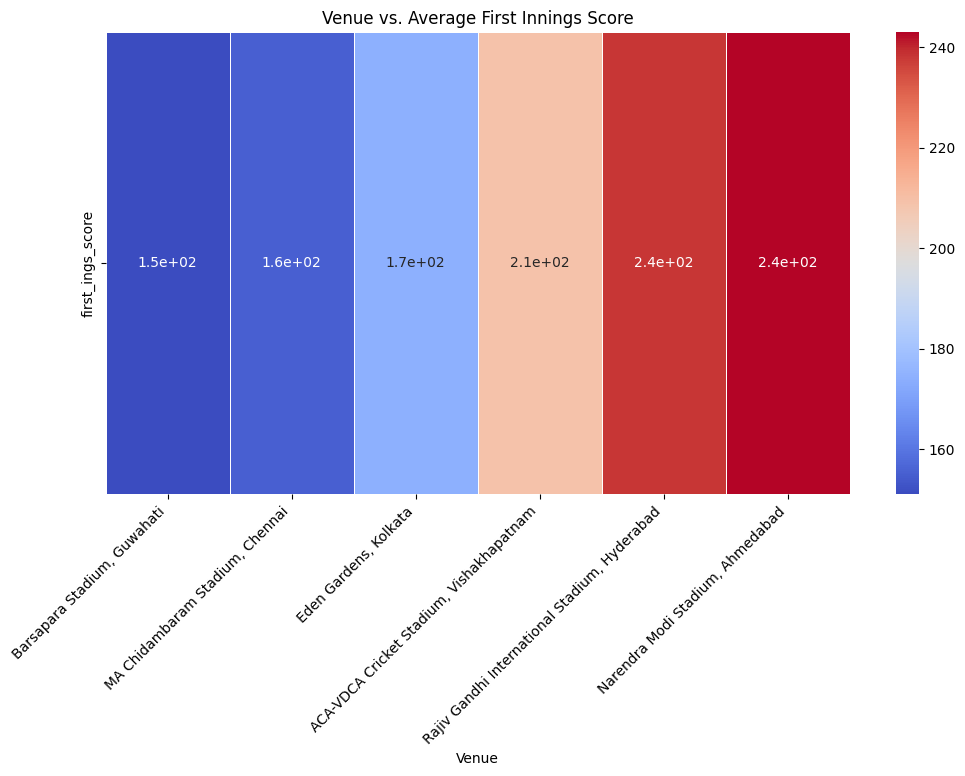

In [18]:
# 6. Heatmap: Venue vs. Average First Innings Score
venue_avg = df.groupby("venue")["first_ings_score"].mean().sort_values()
plt.figure(figsize=(12, 6))
sns.heatmap(venue_avg.to_frame().T, cmap="coolwarm", annot=True, linewidths=0.5)
plt.title("Venue vs. Average First Innings Score")
plt.xlabel("Venue")
plt.xticks(rotation=45, ha="right")
plt.show()

## Thank you!!!..pls upvote!!